# CAPM for IMOEX Constituents as of 24.04.2026

This notebook estimates CAPM for companies included in the IMOEX index as of **24 April 2026**.

Main logic:

1. Download IMOEX constituents from MOEX ISS.
2. Download daily stock prices from MOEX ISS.
3. Download dividends from MOEX ISS and build dividend-adjusted daily total returns.
4. Use a MOEX total return index as the market proxy.
5. Use the Bank of Russia 10-year zero-coupon government yield as the risk-free rate.
6. Estimate CAPM in **daily format** first.
7. Convert daily CAPM results to **annual format**.
8. Build SML, alpha charts, and a ranked beta chart.

Daily CAPM equation:

$$R_{i,t} - R_{f,t} = \alpha_i + \beta_i(R_{m,t} - R_{f,t}) + \varepsilon_{i,t}$$

In [8]:
# ============================================================
# Cell 1. Imports and settings
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from io import StringIO

AS_OF_DATE = "2026-04-24"
START_DATE = "2016-01-01"
TRADING_DAYS = 252
CURRENT_RETURN_WINDOW_DAYS = 252
BATCH_SIZE = 100

# MOEX Russia Total Return Index. If unavailable, replace manually.
MARKET_TOTAL_RETURN_INDEX = "MCFTR"

OUTPUT_XLSX = f"imoex_capm_results_{AS_OF_DATE}.xlsx"

## 1. MOEX ISS parsers

The following functions use the same MOEX ISS logic: request JSON data, select a table, and convert it into a pandas DataFrame. Historical data is downloaded page by page with the `start` parameter.

In [9]:
# ============================================================
# Cell 2. MOEX ISS parsers
# ============================================================

def moex_get_table(url, table_name, params=None, timeout=30):
    params = params or {}
    params.setdefault("iss.meta", "off")

    response = requests.get(url, params=params, timeout=timeout)
    response.raise_for_status()
    data = response.json()

    if table_name not in data:
        return pd.DataFrame()

    table = data[table_name]
    return pd.DataFrame(table["data"], columns=table["columns"])


def get_moex_paginated_history(url, start_date, end_date, table_name="history", extra_params=None):
    rows = []
    start = 0
    extra_params = extra_params or {}

    while True:
        params = {
            "from": start_date,
            "till": end_date,
            "start": start,
            "iss.meta": "off"
        }
        params.update(extra_params)

        df = moex_get_table(url, table_name, params=params)

        if df.empty:
            break

        rows.append(df)

        if len(df) < BATCH_SIZE:
            break

        start += BATCH_SIZE

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)

    if "TRADEDATE" in out.columns:
        out["TRADEDATE"] = pd.to_datetime(out["TRADEDATE"])
        out = out.sort_values("TRADEDATE")

    return out


def get_stock_history(secid, start_date, end_date, board="TQBR"):
    url = (
        "https://iss.moex.com/iss/history/engines/stock/"
        f"markets/shares/boards/{board}/securities/{secid}.json"
    )
    return get_moex_paginated_history(url, start_date, end_date)


def get_index_history(secid, start_date, end_date):
    url = (
        "https://iss.moex.com/iss/history/engines/stock/"
        f"markets/index/securities/{secid}.json"
    )
    return get_moex_paginated_history(url, start_date, end_date)

## 2. IMOEX constituents on 24.04.2026

This block downloads the list of IMOEX constituents from MOEX index analytics for the selected date.

In [10]:
# ============================================================
# Cell 3. IMOEX constituents
# ============================================================

def get_imoex_constituents(as_of_date):
    url = (
        "https://iss.moex.com/iss/statistics/engines/stock/"
        "markets/index/analytics/IMOEX.json"
    )

    params = {"date": as_of_date, "iss.meta": "off"}
    df = moex_get_table(url, "analytics", params=params)

    if df.empty:
        raise ValueError("IMOEX constituents were not loaded. Check MOEX ISS endpoint/date.")

    possible_ticker_cols = ["SECID", "secid", "ticker", "TICKER"]
    ticker_col = next((c for c in possible_ticker_cols if c in df.columns), None)

    if ticker_col is None:
        print("Available columns:", df.columns.tolist())
        raise ValueError("Ticker column was not found in MOEX analytics table.")

    tickers = (
        df[ticker_col]
        .dropna()
        .astype(str)
        .str.upper()
        .unique()
        .tolist()
    )

    return tickers, df


imoex_tickers, imoex_table = get_imoex_constituents(AS_OF_DATE)
print(f"Number of IMOEX constituents on {AS_OF_DATE}: {len(imoex_tickers)}")
print(imoex_tickers)
display(imoex_table.head())

Number of IMOEX constituents on 2026-04-24: 20
['AFKS', 'AFLT', 'ALRS', 'BSPB', 'CBOM', 'CHMF', 'CNRU', 'DOMRF', 'ENPG', 'FLOT', 'GAZP', 'GMKN', 'HEAD', 'IRAO', 'LENT', 'LKOH', 'MAGN', 'MDMG', 'MOEX', 'MSNG']


,indexid,tradedate,ticker,shortnames,secids,weight,tradingsession,trade_session_date
0,IMOEX,2026-04-24,AFKS,Система ао,AFKS,0.32,3,2026-04-24
1,IMOEX,2026-04-24,AFLT,Аэрофлот,AFLT,0.54,3,2026-04-24
2,IMOEX,2026-04-24,ALRS,АЛРОСА ао,ALRS,0.42,3,2026-04-24
3,IMOEX,2026-04-24,BSPB,БСП ао,BSPB,0.35,3,2026-04-24
4,IMOEX,2026-04-24,CBOM,МКБ ао,CBOM,0.47,3,2026-04-24


## 3. Dividend-adjusted total returns

CAPM should be estimated on returns that include dividends. Daily total return is approximated as:

$$R_{i,t}^{TR}=\frac{P_{i,t}+D_{i,t}}{P_{i,t-1}}-1$$

Dividend is assigned to the first trading day on or after the registry close date. This is a practical approximation for MOEX ISS data.

In [11]:
# ============================================================
# Cell 4. Dividends and total return series
# ============================================================

def select_price_column(df):
    for col in ["LEGALCLOSEPRICE", "CLOSE", "WAPRICE", "MARKETPRICE3", "ADMITTEDQUOTE"]:
        if col in df.columns:
            return col
    raise ValueError(f"No suitable price column found. Available columns: {df.columns.tolist()}")


def get_dividends_for_ticker(ticker):
    url = f"https://iss.moex.com/iss/securities/{ticker}/dividends.json"

    try:
        df = moex_get_table(url, "dividends", params={"iss.meta": "off"})
    except Exception as e:
        print(f"Dividend loading error for {ticker}: {e}")
        return pd.DataFrame(columns=["SECID", "Registry_Date", "Dividend"])

    if df.empty:
        return pd.DataFrame(columns=["SECID", "Registry_Date", "Dividend"])

    possible_date_cols = [
        "registryclosedate", "Registry_Date", "REGISTRYCLOSEDATE",
        "registry_close_date", "recorddate", "RECORDDATE"
    ]
    possible_div_cols = ["value", "Dividend", "VALUE", "dividend", "DIVIDEND"]

    date_col = next((c for c in possible_date_cols if c in df.columns), None)
    div_col = next((c for c in possible_div_cols if c in df.columns), None)

    if date_col is None or div_col is None:
        print(f"Unexpected dividend columns for {ticker}: {df.columns.tolist()}")
        return pd.DataFrame(columns=["SECID", "Registry_Date", "Dividend"])

    out = pd.DataFrame({
        "SECID": ticker,
        "Registry_Date": pd.to_datetime(df[date_col], errors="coerce"),
        "Dividend": pd.to_numeric(df[div_col], errors="coerce")
    })
    return out.dropna(subset=["Registry_Date", "Dividend"])


def build_total_return_series(ticker, start_date, end_date, board="TQBR"):
    quotes = get_stock_history(ticker, start_date, end_date, board=board)

    if quotes.empty:
        return pd.Series(dtype=float, name=ticker)

    price_col = select_price_column(quotes)

    prices = quotes[["TRADEDATE", price_col]].copy()
    prices = prices.rename(columns={price_col: "price"})
    prices["price"] = pd.to_numeric(prices["price"], errors="coerce")
    prices = prices.dropna(subset=["price"])
    prices = prices.drop_duplicates("TRADEDATE")
    prices = prices.set_index("TRADEDATE").sort_index()

    dividends = get_dividends_for_ticker(ticker)
    dividends = dividends[
        (dividends["Registry_Date"] >= pd.to_datetime(start_date)) &
        (dividends["Registry_Date"] <= pd.to_datetime(end_date))
    ]

    prices["dividend"] = 0.0

    for _, row in dividends.iterrows():
        registry_date = row["Registry_Date"]
        dividend = row["Dividend"]
        possible_dates = prices.index[prices.index >= registry_date]
        if len(possible_dates) > 0:
            prices.loc[possible_dates[0], "dividend"] += dividend

    prices["total_return"] = (prices["price"] + prices["dividend"]) / prices["price"].shift(1) - 1
    return prices["total_return"].dropna().rename(ticker)

## 4. Build the matrix of stock total returns

The next cell downloads all IMOEX stock return series and combines them into one DataFrame. Stocks with less than one year of daily observations are skipped.

In [12]:
# ============================================================
# Cell 5. Asset total return matrix
# ============================================================

all_returns = []
failed_tickers = []

for ticker in imoex_tickers:
    try:
        r = build_total_return_series(ticker, START_DATE, AS_OF_DATE)

        if len(r) >= TRADING_DAYS:
            all_returns.append(r)
        else:
            failed_tickers.append((ticker, "not enough observations"))
            print(f"Skipped {ticker}: not enough observations")

    except Exception as e:
        failed_tickers.append((ticker, str(e)))
        print(f"Skipped {ticker}: {e}")

if not all_returns:
    raise ValueError("No stock return series were built. Check data availability and parsers.")

asset_returns = pd.concat(all_returns, axis=1).sort_index()

print("Asset return matrix shape:", asset_returns.shape)
print("Loaded tickers:", asset_returns.columns.tolist())
32
if failed_tickers:
    print("\nFailed or skipped tickers:")
    for item in failed_tickers:
        print(item)

display(asset_returns.head())

Skipped DOMRF: not enough observations
Asset return matrix shape: (2608, 19)
Loaded tickers: ['AFKS', 'AFLT', 'ALRS', 'BSPB', 'CBOM', 'CHMF', 'CNRU', 'ENPG', 'FLOT', 'GAZP', 'GMKN', 'HEAD', 'IRAO', 'LENT', 'LKOH', 'MAGN', 'MDMG', 'MOEX', 'MSNG']

Failed or skipped tickers:
('DOMRF', 'not enough observations')


,AFKS,AFLT,ALRS,BSPB,CBOM,CHMF,CNRU,ENPG,FLOT,GAZP,GMKN,HEAD,IRAO,LENT,LKOH,MAGN,MDMG,MOEX,MSNG
TRADEDATE,,,,,,,,,,,,,,,,,,,
2016-01-05,0.026644,-0.031139,0.046912,-0.006857,-0.016539,0.025778,NaN,NaN,NaN,0.011415,0.018269,NaN,0.112647,NaN,0.030214,0.006908,NaN,0.026674,0.040804
2016-01-06,-0.000828,-0.007346,-0.001903,0.004603,0.005175,0.044060,NaN,NaN,NaN,-0.003738,-0.010457,NaN,0.038012,NaN,-0.000840,0.016887,NaN,0.001485,-0.006437
2016-01-11,-0.028737,-0.036818,-0.027388,-0.013746,-0.002574,-0.032666,NaN,NaN,NaN,-0.033544,-0.043382,NaN,-0.039437,NaN,-0.050505,-0.030358,NaN,0.000635,-0.029446
2016-01-12,-0.000853,0.022858,0.039743,0.006969,-0.014194,0.001777,NaN,NaN,NaN,0.016441,-0.005465,NaN,-0.007331,NaN,-0.015235,-0.021408,NaN,-0.007937,0.004248
2016-01-13,-0.000285,0.032864,-0.012513,-0.004614,-0.013089,-0.014032,NaN,NaN,NaN,-0.016774,0.007132,NaN,-0.024742,NaN,0.000675,-0.023790,NaN,-0.022933,-0.006647


## 5. Market total return index

Because stock returns include dividends, the market proxy should also be a total return index. The market return is calculated as the daily percentage change in the total return index level.

In [13]:
# ============================================================
# Cell 6. Market total return index
# ============================================================

market_df = get_index_history(MARKET_TOTAL_RETURN_INDEX, START_DATE, AS_OF_DATE)

if market_df.empty:
    raise ValueError(f"Market index {MARKET_TOTAL_RETURN_INDEX} was not loaded.")

market_price_col = select_price_column(market_df)

market_series = (
    market_df[["TRADEDATE", market_price_col]]
    .rename(columns={market_price_col: "market"})
    .dropna()
    .drop_duplicates("TRADEDATE")
    .set_index("TRADEDATE")
    .sort_index()
)
market_series["market"] = pd.to_numeric(market_series["market"], errors="coerce")
market_series = market_series.dropna()

market_returns = market_series["market"].pct_change().dropna().rename("market_return")

print("Market return observations:", len(market_returns))
display(market_returns.head())

Market return observations: 2588


,market_return
TRADEDATE,
2016-01-05,0.012609
2016-01-06,-0.003170
2016-01-11,-0.037759
2016-01-12,0.004609
2016-01-13,-0.003264


## 6. Risk-free rate: Bank of Russia 10-year zero-coupon yield

The annual 10-year zero-coupon yield is parsed from the Bank of Russia curve and converted to the daily rate:

$$R_{f,daily}=(1+R_{f,annual})^{1/252}-1$$

In [16]:
# ============================================================
# Cell 7. CBR 10-year zero-coupon risk-free rate
# ============================================================

import re
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from datetime import datetime

def get_cbr_10y_zero_coupon_rate(as_of_date, fallback_10y_rate_pct=None):
    """
    Parse CBR zero-coupon yield curve and return the interpolated 10Y rate.

    Parameters
    ----------
    as_of_date : str or datetime-like
        Target date.
    fallback_10y_rate_pct : float or None
        Optional fallback value in percent, e.g. 14.26.
        If parsing fails and fallback is provided, the function returns it.

    Returns
    -------
    rf_10y_decimal : float
        10Y zero-coupon rate in decimal form.
    zcyc : pd.DataFrame
        Parsed yield curve table with maturity and yield columns.
    """

    url = "https://www.cbr.ru/hd_base/zcyc_params/zcyc/"
    date_rus = pd.to_datetime(as_of_date).strftime("%d.%m.%Y")

    params = {
        "DateTo": date_rus
    }

    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept-Language": "ru-RU,ru;q=0.9,en;q=0.8",
    }

    try:
        response = requests.get(
            url,
            params=params,
            headers=headers,
            timeout=30
        )
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")
        text = soup.get_text("\n", strip=True).replace("\xa0", " ")

        lines = [
            re.sub(r"\s+", " ", line).strip()
            for line in text.splitlines()
        ]
        lines = [line for line in lines if line]

        maturity_idx = next(
            (i for i, line in enumerate(lines) if "Срок до погашения" in line),
            None
        )

        yield_idx = next(
            (i for i, line in enumerate(lines) if "Доходность" in line and "% годовых" in line),
            None
        )

        if maturity_idx is None or yield_idx is None:
            raise ValueError(
                "Could not find maturity/yield headings on the CBR page."
            )

        def collect_numbers_after(start_idx, stop_idx=None, max_count=12):
            nums = []
            end = stop_idx if stop_idx is not None else len(lines)

            for j in range(start_idx + 1, end):
                found = re.findall(r"\d+(?:[.,]\d+)?", lines[j])
                for x in found:
                    nums.append(float(x.replace(",", ".")))
                    if len(nums) >= max_count:
                        return nums
            return nums

        maturities = collect_numbers_after(
            maturity_idx,
            stop_idx=yield_idx,
            max_count=12
        )

        yields = collect_numbers_after(
            yield_idx,
            stop_idx=None,
            max_count=12
        )

        if len(maturities) != len(yields) or len(maturities) == 0:
            raise ValueError(
                f"Failed to parse CBR curve. "
                f"maturities={maturities}, yields={yields}"
            )

        zcyc = pd.DataFrame({
            "maturity": maturities,
            "yield": yields
        }).sort_values("maturity")

        rf_10y_percent = np.interp(
            10.0,
            zcyc["maturity"],
            zcyc["yield"]
        )

        return rf_10y_percent / 100, zcyc

    except Exception as e:
        if fallback_10y_rate_pct is None:
            raise ValueError(f"CBR ZCYC parsing failed: {e}") from e

        zcyc = pd.DataFrame({
            "maturity": [10.0],
            "yield": [fallback_10y_rate_pct]
        })

        return fallback_10y_rate_pct / 100, zcyc


rf_annual, zcyc_table = get_cbr_10y_zero_coupon_rate(
    AS_OF_DATE,
    fallback_10y_rate_pct=14.26
)

rf_daily = (1 + rf_annual) ** (1 / TRADING_DAYS) - 1

print(f"10Y risk-free rate on {AS_OF_DATE}: {rf_annual:.4%}")
print(f"Daily risk-free rate: {rf_daily:.6%}")
display(zcyc_table)

10Y risk-free rate on 2026-04-24: 14.5200%
Daily risk-free rate: 0.053816%


,maturity,yield
0,0.25,12.64
1,0.50,12.82
2,0.75,12.98
3,1.00,13.11
4,2.00,13.52
5,3.00,13.82
6,5.00,14.25
7,7.00,14.46
8,10.00,14.52
9,15.00,14.44


## 7. Daily CAPM estimation and annual conversion

CAPM is estimated in daily format first:

$$R_{i,daily}-R_{f,daily}=\alpha_{i,daily}+\beta_i(R_{m,daily}-R_{f,daily})+\varepsilon_i$$

Then daily return estimates are annualized by compounding. Beta itself is not annualized.

In [17]:
# ============================================================
# Cell 8. Daily CAPM estimation
# ============================================================

def annualized_geometric_return(daily_returns, trading_days=252):
    daily_returns = daily_returns.dropna()
    if len(daily_returns) == 0:
        return np.nan
    cumulative = (1 + daily_returns).prod()
    years = len(daily_returns) / trading_days
    return cumulative ** (1 / years) - 1


def annualize_daily_rate(daily_rate, trading_days=252):
    return (1 + daily_rate) ** trading_days - 1


common_data = pd.concat([asset_returns, market_returns], axis=1).dropna(subset=["market_return"])
capm_rows = []

for ticker in asset_returns.columns:
    df = common_data[[ticker, "market_return"]].dropna()

    if len(df) < TRADING_DAYS:
        continue

    stock_return = df[ticker]
    market_return = df["market_return"]

    stock_excess = stock_return - rf_daily
    market_excess = market_return - rf_daily

    regression = stats.linregress(market_excess, stock_excess)

    beta = regression.slope
    alpha_daily_ols = regression.intercept
    r_squared = regression.rvalue ** 2
    p_value_beta = regression.pvalue

    stock_mean_daily = stock_return.mean()
    market_mean_daily = market_return.mean()

    capm_expected_daily = rf_daily + beta * (market_mean_daily - rf_daily)
    capm_alpha_daily_mean_based = stock_mean_daily - capm_expected_daily

    actual_mean_annual = annualize_daily_rate(stock_mean_daily, TRADING_DAYS)
    market_mean_annual = annualize_daily_rate(market_mean_daily, TRADING_DAYS)
    capm_expected_annual = annualize_daily_rate(capm_expected_daily, TRADING_DAYS)
    capm_alpha_annual_mean_based = annualize_daily_rate(capm_alpha_daily_mean_based, TRADING_DAYS)

    actual_current_annual = annualized_geometric_return(stock_return.tail(CURRENT_RETURN_WINDOW_DAYS), TRADING_DAYS)
    market_current_annual = annualized_geometric_return(market_return.tail(CURRENT_RETURN_WINDOW_DAYS), TRADING_DAYS)
    capm_expected_current_annual = rf_annual + beta * (market_current_annual - rf_annual)
    capm_alpha_current_annual = actual_current_annual - capm_expected_current_annual

    capm_rows.append({
        "ticker": ticker,
        "beta": beta,
        "alpha_daily_ols": alpha_daily_ols,
        "alpha_annual_ols": annualize_daily_rate(alpha_daily_ols, TRADING_DAYS),
        "actual_mean_daily": stock_mean_daily,
        "market_mean_daily": market_mean_daily,
        "capm_expected_daily": capm_expected_daily,
        "capm_alpha_daily_mean_based": capm_alpha_daily_mean_based,
        "actual_mean_annual": actual_mean_annual,
        "market_mean_annual": market_mean_annual,
        "capm_expected_annual": capm_expected_annual,
        "capm_alpha_annual_mean_based": capm_alpha_annual_mean_based,
        "actual_current_annual_total_return": actual_current_annual,
        "market_current_annual_total_return": market_current_annual,
        "capm_expected_current_annual": capm_expected_current_annual,
        "capm_alpha_current_annual": capm_alpha_current_annual,
        "rf_daily": rf_daily,
        "rf_annual_10y": rf_annual,
        "r_squared": r_squared,
        "p_value_beta": p_value_beta,
        "observations": len(df)
    })

capm = pd.DataFrame(capm_rows)
capm["capm_status"] = np.where(capm["capm_alpha_current_annual"] > 0, "Undervalued by CAPM", "Overvalued by CAPM")
capm = capm.sort_values("capm_alpha_current_annual", ascending=False).reset_index(drop=True)

display(capm.head(30))

,ticker,beta,alpha_daily_ols,alpha_annual_ols,actual_mean_daily,market_mean_daily,capm_expected_daily,capm_alpha_daily_mean_based,actual_mean_annual,market_mean_annual,...,actual_current_annual_total_return,market_current_annual_total_return,capm_expected_current_annual,capm_alpha_current_annual,rf_daily,rf_annual_10y,r_squared,p_value_beta,observations,capm_status
0,LENT,0.708900,0.000588,0.159573,0.000936,0.000271,0.000349,0.000588,0.266030,0.070686,...,0.488046,0.023572,0.058978,0.429068,0.000538,0.1452,0.296109,9.901916e-85,1086,Undervalued by CAPM
1,MDMG,0.603983,0.000740,0.205055,0.001198,0.000405,0.000458,0.000740,0.352183,0.107350,...,0.409528,0.023572,0.071739,0.337789,0.000538,0.1452,0.224356,2.556817e-77,1366,Undervalued by CAPM
2,GMKN,0.821192,-0.000351,-0.084702,0.000209,0.000565,0.000560,-0.000351,0.054013,0.152869,...,0.237041,0.023572,0.045320,0.191721,0.000538,0.1452,0.201495,1.539906e-128,2588,Undervalued by CAPM
3,CNRU,0.515483,0.000108,0.027478,0.000513,0.000280,0.000405,0.000108,0.137912,0.073179,...,0.183427,0.023572,0.082503,0.100925,0.000538,0.1452,0.106283,4.988441e-08,267,Undervalued by CAPM
4,ENPG,1.143814,-0.000379,-0.091184,-0.000017,0.000384,0.000362,-0.000379,-0.004393,0.101594,...,0.051027,0.023572,0.006080,0.044947,0.000538,0.1452,0.543425,5.664289e-265,1545,Undervalued by CAPM
5,IRAO,1.108011,0.000387,0.102505,0.000955,0.000565,0.000568,0.000387,0.271890,0.152869,...,0.013740,0.023572,0.010435,0.003305,0.000538,0.1452,0.427007,4.650786e-315,2588,Undervalued by CAPM
6,MSNG,0.719645,0.000284,0.074211,0.000841,0.000565,0.000557,0.000284,0.236061,0.152869,...,-0.013457,0.023572,0.057671,-0.071128,0.000538,0.1452,0.245367,2.586280e-160,2588,Overvalued by CAPM
7,FLOT,0.925235,-0.000084,-0.021019,0.000361,0.000438,0.000446,-0.000084,0.095302,0.116702,...,-0.048669,0.023572,0.032666,-0.081335,0.000538,0.1452,0.427288,5.824475e-170,1388,Overvalued by CAPM
8,MOEX,0.687128,0.000105,0.026759,0.000661,0.000565,0.000556,0.000105,0.181232,0.152869,...,-0.025559,0.023572,0.061626,-0.087185,0.000538,0.1452,0.339566,2.946978e-235,2588,Overvalued by CAPM
9,HEAD,0.702865,-0.000281,-0.068362,0.000119,0.000342,0.000400,-0.000281,0.030503,0.089957,...,-0.046630,0.023572,0.059712,-0.106343,0.000538,0.1452,0.312958,3.114658e-34,399,Overvalued by CAPM


## 8. Security Market Line

The Security Market Line is:

$$E(R_i)=R_f+\beta_i(E(R_m)-R_f)$$

Stocks above the SML have positive CAPM alpha; stocks below the SML have negative CAPM alpha.

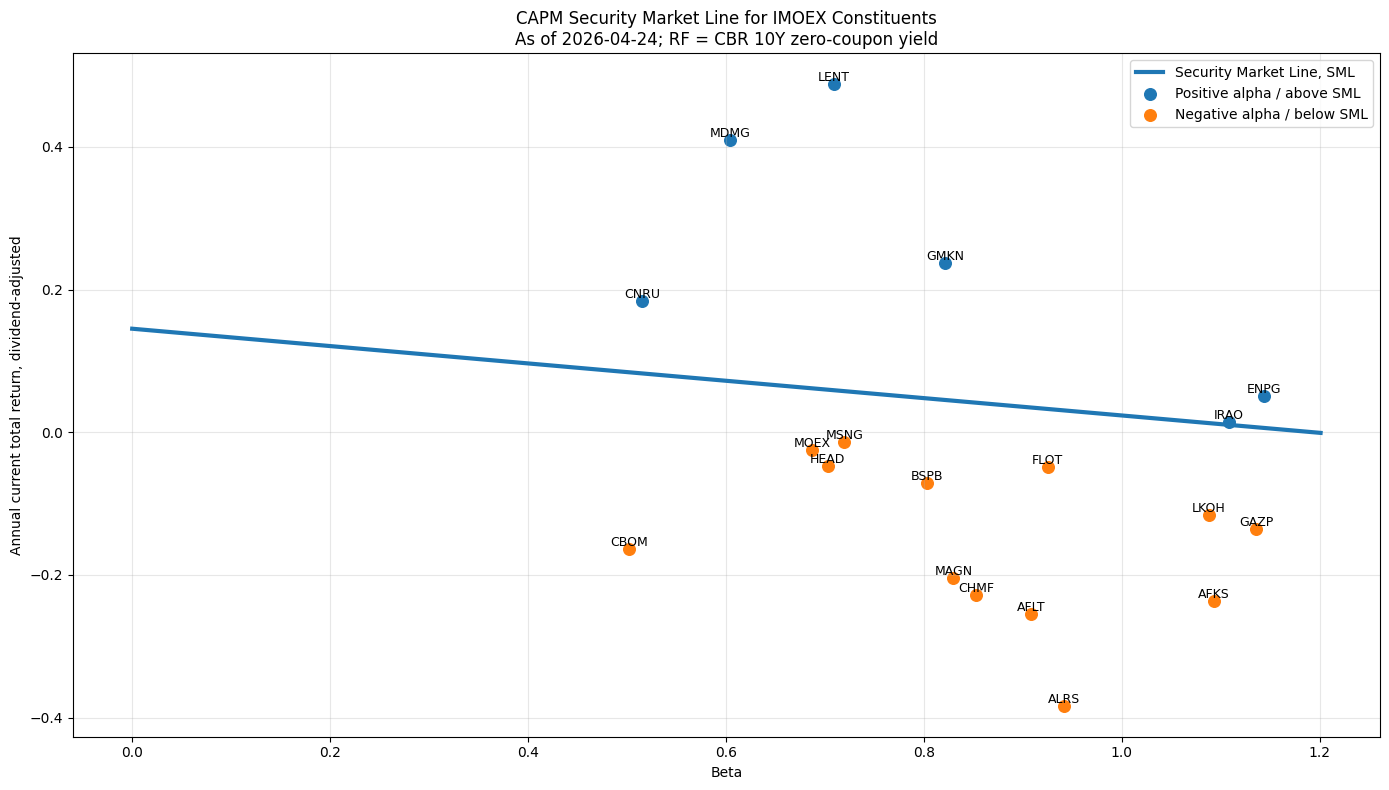

In [18]:
# ============================================================
# Cell 9. Security Market Line chart
# ============================================================

plt.figure(figsize=(14, 8))

x_min = min(0, capm["beta"].min() * 0.95)
x_max = capm["beta"].max() * 1.05
x_line = np.linspace(x_min, x_max, 200)

market_current_annual_for_chart = capm["market_current_annual_total_return"].dropna().iloc[0]
y_line = rf_annual + x_line * (market_current_annual_for_chart - rf_annual)

plt.plot(x_line, y_line, linewidth=3, label="Security Market Line, SML")

positive_alpha = capm[capm["capm_alpha_current_annual"] > 0]
negative_alpha = capm[capm["capm_alpha_current_annual"] <= 0]

plt.scatter(positive_alpha["beta"], positive_alpha["actual_current_annual_total_return"], s=70, label="Positive alpha / above SML")
plt.scatter(negative_alpha["beta"], negative_alpha["actual_current_annual_total_return"], s=70, label="Negative alpha / below SML")

for _, row in capm.iterrows():
    plt.text(row["beta"], row["actual_current_annual_total_return"], row["ticker"], fontsize=9, ha="center", va="bottom")

plt.xlabel("Beta")
plt.ylabel("Annual current total return, dividend-adjusted")
plt.title(f"CAPM Security Market Line for IMOEX Constituents\nAs of {AS_OF_DATE}; RF = CBR 10Y zero-coupon yield")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Alpha chart

This chart shows annual current total return and CAPM alpha. Values above zero indicate positive alpha relative to CAPM.

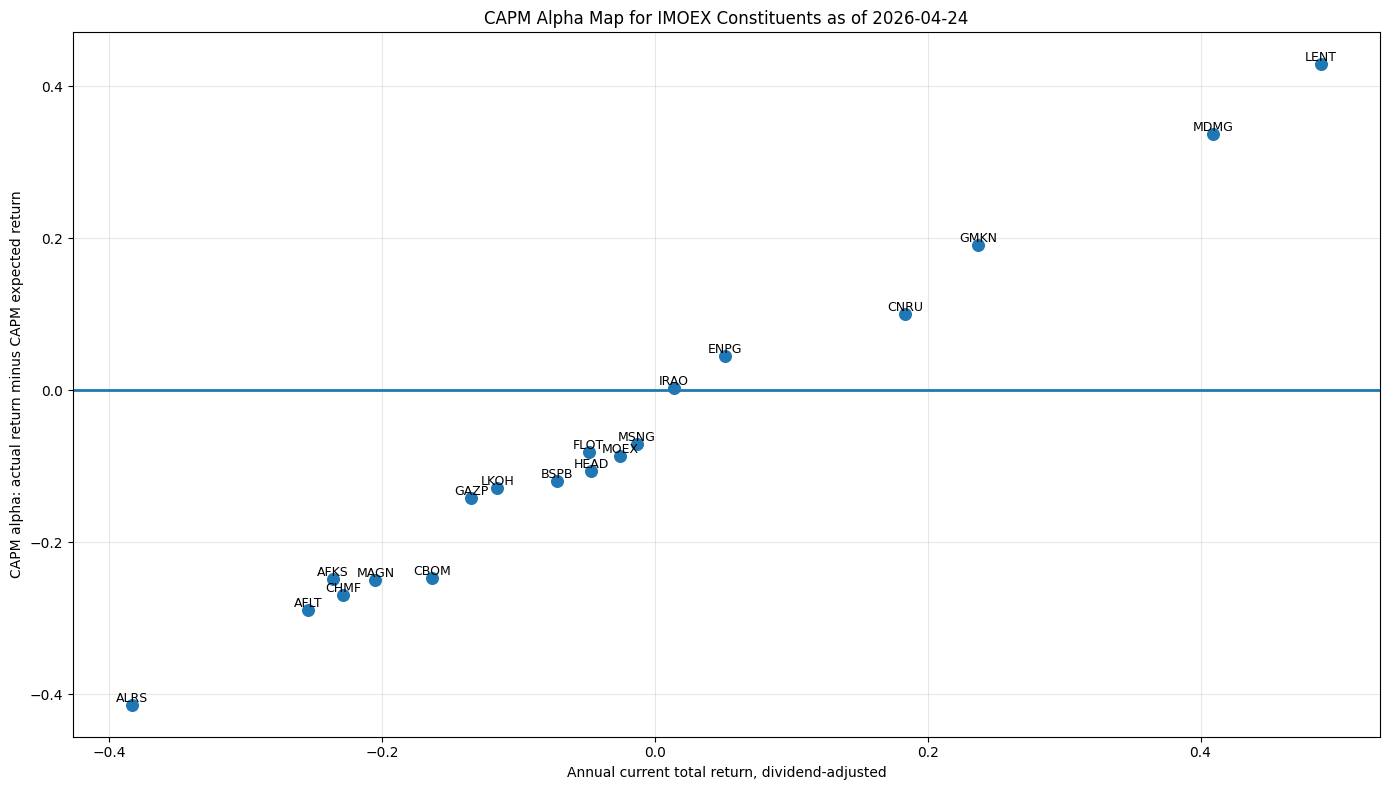

In [19]:
# ============================================================
# Cell 10. Alpha chart
# ============================================================

plt.figure(figsize=(14, 8))
plt.scatter(capm["actual_current_annual_total_return"], capm["capm_alpha_current_annual"], s=70)

for _, row in capm.iterrows():
    plt.text(row["actual_current_annual_total_return"], row["capm_alpha_current_annual"], row["ticker"], fontsize=9, ha="center", va="bottom")

plt.axhline(0, linewidth=2)
plt.xlabel("Annual current total return, dividend-adjusted")
plt.ylabel("CAPM alpha: actual return minus CAPM expected return")
plt.title(f"CAPM Alpha Map for IMOEX Constituents as of {AS_OF_DATE}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Actual return vs CAPM expected return

The diagonal line is the fair-value line. Stocks above the line earned more than CAPM required; stocks below the line earned less.

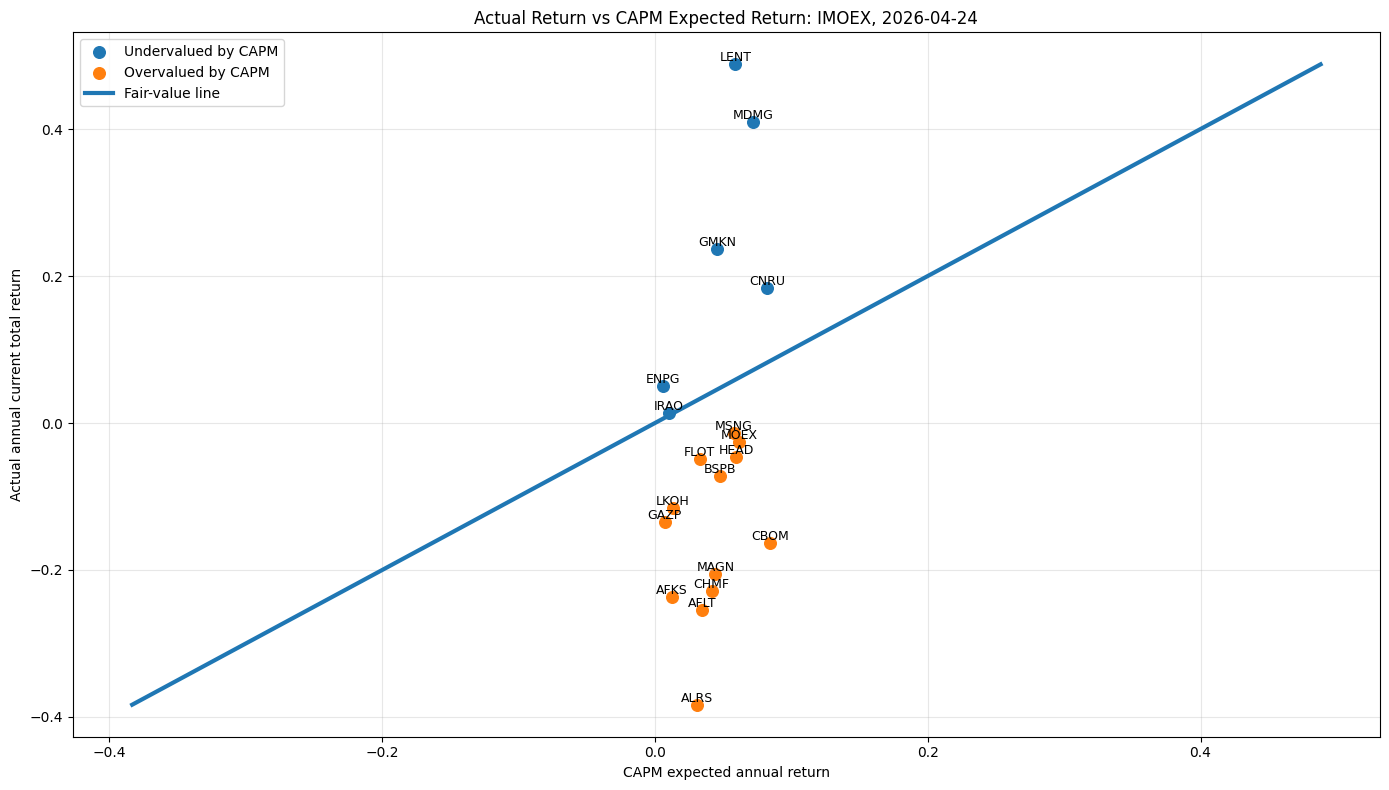

In [20]:
# ============================================================
# Cell 11. Actual vs CAPM expected return
# ============================================================

plt.figure(figsize=(14, 8))

positive_alpha = capm[capm["capm_alpha_current_annual"] > 0]
negative_alpha = capm[capm["capm_alpha_current_annual"] <= 0]

plt.scatter(positive_alpha["capm_expected_current_annual"], positive_alpha["actual_current_annual_total_return"], s=70, label="Undervalued by CAPM")
plt.scatter(negative_alpha["capm_expected_current_annual"], negative_alpha["actual_current_annual_total_return"], s=70, label="Overvalued by CAPM")

min_val = min(capm["capm_expected_current_annual"].min(), capm["actual_current_annual_total_return"].min())
max_val = max(capm["capm_expected_current_annual"].max(), capm["actual_current_annual_total_return"].max())
plt.plot([min_val, max_val], [min_val, max_val], linewidth=3, label="Fair-value line")

for _, row in capm.iterrows():
    plt.text(row["capm_expected_current_annual"], row["actual_current_annual_total_return"], row["ticker"], fontsize=9, ha="center", va="bottom")

plt.xlabel("CAPM expected annual return")
plt.ylabel("Actual annual current total return")
plt.title(f"Actual Return vs CAPM Expected Return: IMOEX, {AS_OF_DATE}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Ranked beta chart

This chart ranks all stocks by CAPM beta.

Interpretation:

- beta above 1: more sensitive than the market;
- beta near 1: market-like sensitivity;
- beta below 1: less sensitive than the market.

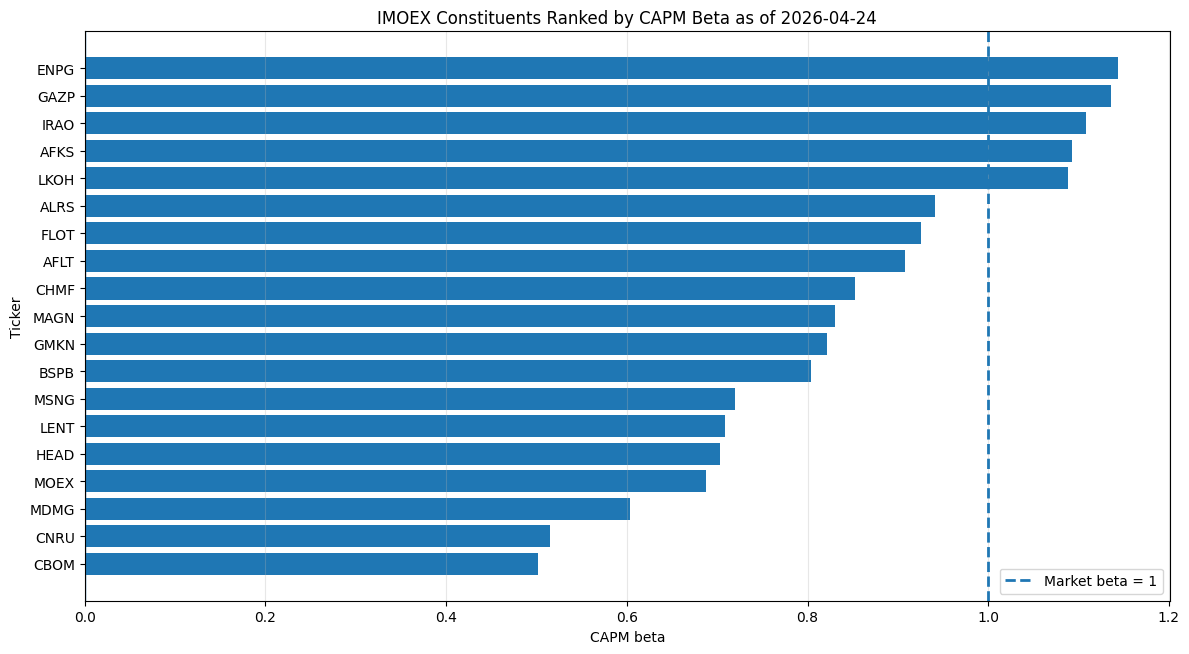

In [21]:
# ============================================================
# Cell 12. Ranked beta chart
# ============================================================

beta_ranked = capm.sort_values("beta", ascending=True).copy()

plt.figure(figsize=(12, max(6, 0.35 * len(beta_ranked))))
plt.barh(beta_ranked["ticker"], beta_ranked["beta"])
plt.axvline(1.0, linewidth=2, linestyle="--", label="Market beta = 1")
plt.axvline(0.0, linewidth=1)
plt.xlabel("CAPM beta")
plt.ylabel("Ticker")
plt.title(f"IMOEX Constituents Ranked by CAPM Beta as of {AS_OF_DATE}")
plt.grid(True, axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Final tables and Excel export

The final block creates two rankings: by alpha and by beta, then saves all outputs into Excel.

In [22]:
# ============================================================
# Cell 13. Final rankings and Excel export
# ============================================================

alpha_ranking = capm.sort_values("capm_alpha_current_annual", ascending=False)[[
    "ticker", "beta", "actual_current_annual_total_return", "capm_expected_current_annual",
    "capm_alpha_current_annual", "capm_status", "r_squared", "observations"
]]

beta_ranking = capm.sort_values("beta", ascending=False)[[
    "ticker", "beta", "capm_alpha_current_annual", "actual_current_annual_total_return",
    "capm_expected_current_annual", "r_squared", "observations"
]]

print("Ranking by CAPM alpha:")
display(alpha_ranking)

print("Ranking by beta:")
display(beta_ranking)

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    capm.to_excel(writer, sheet_name="CAPM_results", index=False)
    alpha_ranking.to_excel(writer, sheet_name="Alpha_ranking", index=False)
    beta_ranking.to_excel(writer, sheet_name="Beta_ranking", index=False)
    asset_returns.to_excel(writer, sheet_name="Asset_total_returns")
    market_returns.to_excel(writer, sheet_name="Market_total_return")
    zcyc_table.to_excel(writer, sheet_name="CBR_ZCYC", index=False)
    imoex_table.to_excel(writer, sheet_name="IMOEX_constituents", index=False)

print(f"Saved Excel file: {OUTPUT_XLSX}")

Ranking by CAPM alpha:


,ticker,beta,actual_current_annual_total_return,capm_expected_current_annual,capm_alpha_current_annual,capm_status,r_squared,observations
0,LENT,0.708900,0.488046,0.058978,0.429068,Undervalued by CAPM,0.296109,1086
1,MDMG,0.603983,0.409528,0.071739,0.337789,Undervalued by CAPM,0.224356,1366
2,GMKN,0.821192,0.237041,0.045320,0.191721,Undervalued by CAPM,0.201495,2588
3,CNRU,0.515483,0.183427,0.082503,0.100925,Undervalued by CAPM,0.106283,267
4,ENPG,1.143814,0.051027,0.006080,0.044947,Undervalued by CAPM,0.543425,1545
5,IRAO,1.108011,0.013740,0.010435,0.003305,Undervalued by CAPM,0.427007,2588
6,MSNG,0.719645,-0.013457,0.057671,-0.071128,Overvalued by CAPM,0.245367,2588
7,FLOT,0.925235,-0.048669,0.032666,-0.081335,Overvalued by CAPM,0.427288,1388
8,MOEX,0.687128,-0.025559,0.061626,-0.087185,Overvalued by CAPM,0.339566,2588
9,HEAD,0.702865,-0.046630,0.059712,-0.106343,Overvalued by CAPM,0.312958,399


Ranking by beta:


,ticker,beta,capm_alpha_current_annual,actual_current_annual_total_return,capm_expected_current_annual,r_squared,observations
4,ENPG,1.143814,0.044947,0.051027,0.006080,0.543425,1545
12,GAZP,1.135630,-0.142036,-0.134960,0.007076,0.514376,2588
5,IRAO,1.108011,0.003305,0.013740,0.010435,0.427007,2588
14,AFKS,1.093216,-0.248347,-0.236113,0.012235,0.407292,2588
11,LKOH,1.087861,-0.128387,-0.115501,0.012886,0.621406,2588
18,ALRS,0.941653,-0.413996,-0.383327,0.030669,0.448249,2588
7,FLOT,0.925235,-0.081335,-0.048669,0.032666,0.427288,1388
17,AFLT,0.908212,-0.289090,-0.254354,0.034736,0.352986,2588
16,CHMF,0.852669,-0.270117,-0.228625,0.041492,0.401294,2588
15,MAGN,0.829991,-0.249233,-0.204983,0.044250,0.356847,2588


Saved Excel file: imoex_capm_results_2026-04-24.xlsx


## Notes on interpretation

Positive CAPM alpha does not automatically prove that a stock is fundamentally undervalued. It means that, over the selected return window, its dividend-adjusted realized return was higher than the CAPM-implied required return.

Limitations:

- CAPM is a one-factor model and ignores size, value, momentum, liquidity, sanctions risk, sector effects, and corporate events.
- Dividend adjustment is approximate because dividends are attached to registry close dates.
- The risk-free rate is a 10-year zero-coupon government yield, while the model is estimated on daily returns.
- Results are sensitive to the market proxy and the return window.